In [1]:
import os
import joblib
import pandas as pd
import tensorflow.compat.v2 as tf
import tensorflow_probability as tfp
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from tensorflow_probability.python.internal import tf_keras
from bayesian_ensamble.ensamble import confidence_prediction, plt_calibration_curve, bayesian_ensamble_predict

In [2]:
tfd = tfp.distributions
IMAGE_SHAPE = [28, 28, 1]
NUM_TRAIN_EXAMPLES = 60000
NUM_HELDOUT_EXAMPLES = 10000
NUM_CLASSES = 10
def create_model():
    """Creates a Keras model using LeNet-5 architecture.
    
    Returns:
        model: Compiled Keras model.
    """

    kl_divergence_function = (lambda q, p, _: tfd.kl_divergence(q, p) /
                              tf.cast(NUM_TRAIN_EXAMPLES, dtype=tf.float32))
    
    model = tf_keras.models.Sequential([
        tfp.layers.Convolution2DFlipout(
            6, kernel_size=5, padding='SAME',
            kernel_divergence_fn=kl_divergence_function,
            activation=tf.nn.relu),
        tf_keras.layers.MaxPooling2D(
            pool_size=[2, 2], strides=[2,2],
            padding='SAME'),
        tfp.layers.Convolution2DFlipout(
            16, kernel_size=5, padding='SAME',
            kernel_divergence_fn=kl_divergence_function,
            activation=tf.nn.relu),
        tf_keras.layers.MaxPooling2D(
            pool_size=[2, 2], strides=[2, 2],
            padding='SAME'),
        tfp.layers.Convolution2DFlipout(
            120, kernel_size=5, padding='SAME',
            kernel_divergence_fn=kl_divergence_function,
            activation=tf.nn.relu),
        tf_keras.layers.Flatten(),
        tfp.layers.DenseFlipout(
            84, kernel_divergence_fn=kl_divergence_function,
            activation=tf.nn.relu),
        tfp.layers.DenseFlipout(
            NUM_CLASSES, kernel_divergence_fn=kl_divergence_function,
            activation=tf.nn.softmax)
    ])
    optimizer = tf_keras.optimizers.legacy.Adam(lr=0.001)
    model.compile(optimizer, loss= 'categorical_crossentropy',
                  metrics=['accuracy'], experimental_run_tf_function=False)
    return model

In [3]:
svm_linear = joblib.load('mnist_svm_linear.pkl')
svm_rbf = joblib.load('mnist_svm_non_linear.pkl')

bnn_model = create_model()
bnn_model.build(input_shape=[None, 28, 28, 1])
bnn_model.load_weights('final_model.keras')

model_dir = 'cnn_models'
model_list = [bnn_model, svm_linear, svm_rbf]

files = sorted([f for f in os.listdir(model_dir) if f.endswith('.keras')])

for filename in files:
    path = os.path.join(model_dir, filename)
    model_list.append(load_model(path))

print(f"{len(model_list)} model(s) ready for loading")


/Users/knganga1/Documents/Projects/discrete_math/learn tensorflow/.venv/lib/python3.13/site-packages/tf_keras/src/optimizers/legacy/adam.py:118: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)
/Users/knganga1/Documents/Projects/discrete_math/learn tensorflow/.venv/lib/python3.13/site-packages/tensorflow_probability/python/layers/util.py:99: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  loc = add_variable_fn(
/Users/knganga1/Documents/Projects/discrete_math/learn tensorflow/.venv/lib/python3.13/site-packages/tensorflow_probability/python/layers/util.py:109: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  untransformed_scale = add_variable_fn(
/Users/knganga1/Documents/Projects/discrete_math/learn tensorflow/.venv/lib/python3.13/site-pack

18 model(s) ready for loading


In [4]:
digits = pd.read_csv("input/svm/test.csv")/255.0

probs, conf, var = bayesian_ensamble_predict(model_list, digits[:10])

print("Stacking successful!")
print(f"Probabilities Shape: {probs.shape}")
print(f"Confidence Scores: {conf}")

final_results = confidence_prediction(digits[:10], model_list, threshold=0.95)

Stacking successful!
Probabilities Shape: (10, 10)
Confidence Scores: [0.97930227 0.95219033 0.88921593 0.8406818  0.90175344 0.88886638
 0.97953336 0.98446857 0.89642729 0.91851857]
Sample 0: PREDICT 2 (Confidence: 0.9791) | Disagreement (Var): 0.001100
Sample 1: PREDICT 0 (Confidence: 0.9522) | Disagreement (Var): 0.005539
Sample 2: REJECT - Escalate to backup system (Confidence: 0.8943) | Disagreement (Var): 0.014140
Sample 3: REJECT - Escalate to backup system (Confidence: 0.8435) | Disagreement (Var): 0.017218
Sample 4: REJECT - Escalate to backup system (Confidence: 0.9004) | Disagreement (Var): 0.012737
Sample 5: REJECT - Escalate to backup system (Confidence: 0.8842) | Disagreement (Var): 0.014487
Sample 6: PREDICT 0 (Confidence: 0.9795) | Disagreement (Var): 0.000865
Sample 7: PREDICT 3 (Confidence: 0.9856) | Disagreement (Var): 0.000249
Sample 8: REJECT - Escalate to backup system (Confidence: 0.8955) | Disagreement (Var): 0.015856
Sample 9: REJECT - Escalate to backup system

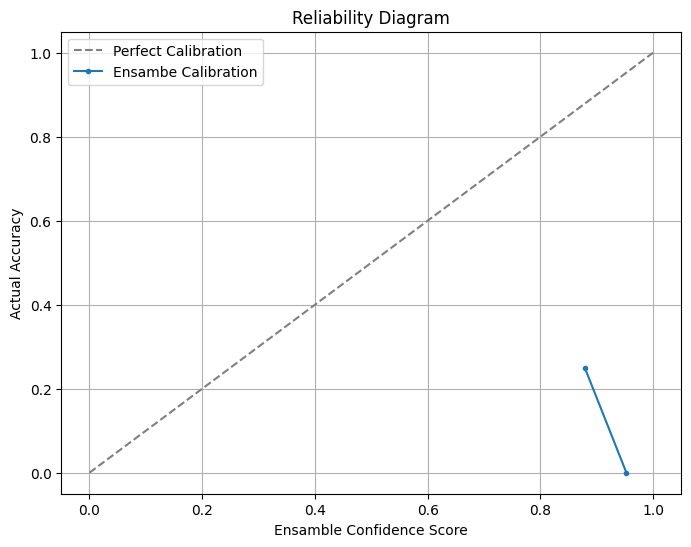

In [5]:
digits_train = pd.read_csv("input/svm/train.csv")
X = digits_train.iloc[:, 1:].values
Y = digits_train.iloc[:, 0].values
X = X/255.0
x_train, x_val, y_train, y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)
plt_calibration_curve(y_val[:10], probs)